# Машинное обучение, ШАД

## Exploratory Data Analysis (EDA)

В любой задаче, связанной с анализом данных, первым шагом всегда становится знакомство с самим датасетом. Прежде чем строить модели или делать выводы, важно оценить структуру, полноту и качество информации. Такой осмысленный подход к предварительному изучению данных получил название *Exploratory Data Analysis (EDA)*, он позволяет выявить проблемы, обнаружить закономерности и определить направления для дальнейшей работы.

### 1. Цели EDA

**EDA (разведочный анализ данных)** помогает понять, с какими данными мы имеем дело, насколько они пригодны для анализа и в каком направлении двигаться дальше. В рамках этого анализа мы ставим следующие цели:

---

#### 1.1. Проверить качество и надёжность данных
- Обнаружить пропущенные, дубликатные или странные значения.
- Найти несоответствия в формате (например, `'male'` и `'Male'` в колонке пола).
- Определить, какие признаки не несут полезной информации или имеют подозрительное распределение.

---

#### 1.2. Оценить распределение признаков и пригодность данных к анализу
- Проверить, насколько сбалансированы классы или категории.
- Найти колонки с одним уникальным значением или нерепрезентативным содержанием.
- Убедиться, что данные позволяют ответить на поставленные вопросы.
  - *Пример*: если нужно сравнить интеллект котов и собак, а котов всего 3, — такой анализ не имеет смысла.
  - *Пример*: если нужно проверить, реже ли имеют детей образованные люди, а в выборке перекос по возрасту и доходу — нужно учитывать это в дальнейшем анализе или запросить другие данные.

  Пример из жизни: сейчас в Великобритании женщины 18-24 лет зарабатывают больше мужчин того же возраста на 10%. Если бы нам дали датасет, в котором мужчины и женщины имеют разное возрастное распределение, то анализ был бы не совсем честным.

---

#### 1.3. Сформулировать гипотезы, связанные с целевой переменной
- Предположить, какие признаки могут влиять на целевую переменную.
- Подготовиться к следующему этапу — построению модели или проверке статистических зависимостей.
- *Пример гипотезы*: «Образованные люди реже имеют детей», «Стаж влияет на уровень зарплаты», и т.п.

---

#### 1.4. Подготовиться самому и подготовить данные к МЛ


- Выявить ключевые признаки: EDA показывает, какие признаки связаны с таргетом. Это помогает выбрать релевантные фичи или создать новые.

- Выбор модели: EDA показывает, подходит ли модель для данных. Если зависимости линейные, можно рассмотреть логистическую регрессию, но kNN хорош для нелинейных паттернов.

- Feature engineering: Создание признаков, например, иногда агрегированные метрики лучше разделяют классы.
- Обработка данных: пропуски, выбросы и стандартизации. EDA помогает выявить аномалии и обработать их.
- Интерпретация для бизнеса. Например, "Клиент X предсказан как откликнувшийся, так как его ближайшие соседи (похожие по доходу и активности) откликнулись."


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math
import scipy.stats as sps
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report
import random
from sklearn.model_selection import cross_val_score
from scipy.stats import ttest_ind, ttest_rel
from sklearn.preprocessing import OneHotEncoder

sns.set(palette="pastel", style="whitegrid", font_scale=1.3)

import warnings

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

### 2. Работа с данными


#### 2.1 Описание данных

**Retail** — идеальная среда для машинного обучения (ML), так как маркетплейсы генерируют огромные объемы данных: о товарах, поведении пользователей, покупках. Эти данные позволяют строить модели, предсказывающие действия клиентов, например, отклик на маркетинговую кампанию (`Response`). ML в retail открывает возможности для таргетинга, оптимизации кампаний и повышения экономических метрик компании.

Для бизнеса ML — это не просто “человек с моделями”. Это специалист, который использует данные для **принятия решений**. Его задача — находить закономерности (например, кто откликнется на акцию), обучать модели (такие как kNN) и предоставлять бизнесу интерпретируемые предсказания для оптимизации стратегий.

---

**Описание датасета**

Мы будем работать с [датасетом маркетинговой кампании](https://www.kaggle.com/X_trainsets/ahsan81/superstore-marketing-campaign-dataset).

Ниже — описание признаков, данные собраны за последние два года до прошлогодней кампании, `Response` — отклик клиента на прошлую коммуникацию:

| Название столбца         | Описание                                                                 |
|---------------------------|--------------------------------------------------------------------------|
| **Response**              | Целевая переменная: `1`, если клиент принял предложение, иначе `0`       |
| **ID**                    | Уникальный идентификатор клиента                                        |
| **Year_Birth**            | Год рождения клиента                                                    |
| **Complain**              | `1`, если клиент жаловался за последние 2 года                           |
| **Dt_Customer**           | Дата регистрации клиента в компании                                     |
| **Education**             | Уровень образования клиента                                             |
| **Marital**               | Семейное положение клиента                                              |
| **Kidhome**               | Количество маленьких детей в семье                                      |
| **Teenhome**              | Количество подростков в семье                                           |
| **Income**                | Годовой доход домохозяйства клиента                                     |
| **MntFishProducts**       | Потрачено на рыбу за последние 2 года                                   |
| **MntMeatProducts**       | Потрачено на мясо                                                       |
| **MntFruits**             | Потрачено на фрукты                                                     |
| **MntSweetProducts**      | Потрачено на сладости                                                   |
| **MntWines**              | Потрачено на вино                                                       |
| **MntGoldProds**          | Потрачено на золотые товары                                             |
| **NumDealsPurchases**     | Количество покупок по скидкам                                           |
| **NumCatalogPurchases**   | Количество покупок по каталогу (доставка)                               |
| **NumStorePurchases**     | Количество покупок в офлайн-магазинах                                   |
| **NumWebPurchases**       | Количество покупок через сайт                                           |
| **NumWebVisitsMonth**     | Количество визитов на сайт за последний месяц                           |
| **Recency**               | Сколько дней назад была последняя покупка                               |

---

**Вопрос бизнеса**

Магазин хочет понять:

> **Насколько вероятно, что покупатель ответит положительно на рекламное предложение?**

Если удастся найти закономерности, можно **таргетировать кампанию** только на тех, кто с высокой вероятностью откликнется — и тем самым сократить издержки.


---

**Условия кампании**

Рекламная кампания: клиент получает **скидочную карту за 500 у.е.**, которая дает скидку на 20% от стоимости (в другие дни цена такой карты — 900).

> _Здесь можно предложить любую кампанию — главное, чтобы она имела понятную **стоимость** для бизнеса и потенциальную **ценность** для клиента._

---


> **Зачем вообще делать анализ? Почему не разослать предложение всем клиентам?**

Потому что это **дорого**. Каждая карта стоит денег, и если отправить её всем подряд, то:
- многие не откликнутся (а ресурсы будут потрачены);
- кампания может стать убыточной;
- может пострадать восприятие бренда (слишком частые/некорректные рассылки).

Поэтому наша задача — **найти признаки, по которым можно предсказать отклик.**

---

**Гипотезы**

&#x2753; **Вопрос** &#x2753;

> **Какие признаки, по вашему мнению, могут влиять на то, откликнется ли клиент?**

- Чем больше клиент тратит, тем выше вероятность, что он купит карту?
- Клиенты с детьми экономнее?
- Пожилые клиенты менее склонны участвовать в акциях?
- Жалобы в прошлом снижают вероятность отклика? Или наоборот, можно разослать кампанию тем, кто жаловался, и тогда они вернутся к нам снова?
---

Начнем с исследования данных, пока отложим вопрос бизнеса на потом.



#### 2.2. Работа с датасетом

Теперь посмотрим на данные: как они выглядят, что с ними можно сделать, чтобы были более удобные.

In [2]:
data = pd.read_csv("superstore_data.csv")
data

,Id,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Response,Complain
0,1826,1970,Graduation,Divorced,84835.0,0,0,6/16/2014,0,189,...,111,189,218,1,4,4,6,1,1,0
1,1,1961,Graduation,Single,57091.0,0,0,6/15/2014,0,464,...,7,0,37,1,7,3,7,5,1,0
2,10476,1958,Graduation,Married,67267.0,0,1,5/13/2014,0,134,...,15,2,30,1,3,2,5,2,0,0
3,1386,1967,Graduation,Together,32474.0,1,1,11/5/2014,0,10,...,0,0,0,1,1,0,2,7,0,0
4,5371,1989,Graduation,Single,21474.0,1,0,8/4/2014,0,6,...,11,0,34,2,3,1,2,7,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10142,1976,PhD,Divorced,66476.0,0,1,7/3/2013,99,372,...,47,48,78,2,5,2,11,4,0,0
2236,5263,1977,2n Cycle,Married,31056.0,1,0,1/22/2013,99,5,...,3,8,16,1,1,0,3,8,0,0
2237,22,1976,Graduation,Divorced,46310.0,1,0,3/12/2012,99,185,...,15,5,14,2,6,1,5,8,0,0
2238,528,1978,Graduation,Married,65819.0,0,0,11/29/2012,99,267,...,149,165,63,1,5,4,10,3,0,0


In [3]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Id                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

У нас есть несколько пропущенных значений в столбце дохода. Можно сделать следующее:
<details>

  - выкинуть

  - заполнить абсурдными значениями (-1 или 1e10, например)  

  - заполнить медианой, средним или каким-то другим способом  

Это решение будет зависеть от поставленной задачи.
</details>

Так как их совсем немного, можно их просто исключить.

In [4]:
data = data[data["Income"].notna()].copy()

Проверим, есть ли дубликаты. Такое бывает, могли быть проблемы с join'ами во время сборки датасета.


In [5]:
duplicate_rows = data.duplicated()
print(f"Полных дубликатов: {duplicate_rows.sum()}")

Полных дубликатов: 0


In [6]:
duplicate_rows = data["Id"].duplicated()
print(f"Дубликаты клиентов: {duplicate_rows.sum()}")

Дубликаты клиентов: 0


Видим, что в данных присутствует личная информация о клиентах:

- возраст,

- семейное положение,

- образование

- количество маленьких детей и взрослых детей

а также поведенческие характеристики:

- количество и сумма покупок,

- покупки со скидками,

- покупки в магазине и на сайте,

- количество просмотров

и т.д. Также есть столбцы `Response` — отклик на прошлую рекламную кампанию, и `Complain` — наличие жалоб клиента за последние два года.

&#x2753; **Вопрос** &#x2753;

> Какие новые признаки можно добавить для улучшения анализа данных?

<details> <summary>Открыть объяснение</summary>

Примеры новых признаков:

* Объединить количество детей и подростков в общий признак `Total_Children`
* Рассчитать `Total_Spent` — общую сумму покупок, просуммировав траты по всем категориям
* Вместо даты рождения добавить возраст клиента (если точный год неизвестен, можно задать его приближённо)

</details><br/>

In [7]:
data["Dt_Customer"] = pd.to_datetime(data["Dt_Customer"], format="%m/%d/%Y")
data["Total_Children"] = data["Kidhome"] + data["Teenhome"]
data["Total_Spent"] = data[
    [
        "MntWines",
        "MntFruits",
        "MntMeatProducts",
        "MntFishProducts",
        "MntSweetProducts",
        "MntGoldProds",
    ]
].sum(axis=1)

У нас есть категориальные и числовые признаки.

**Категориальные**— это признаки, которые принимают ограниченное число значений (например: пол, образование, “да/нет”), и обычно не имеют арифметического смысла — их не стоит складывать, делить или напрямую сравнивать по величине.

**Числовые** признаки, наоборот, имеют количественную природу — их можно усреднять, сравнивать (больше/меньше), использовать в вычислениях.

Разделим сразу признаки на группы и выделим таргетную переменную:

In [8]:
cat_columns = ["Education", "Marital_Status", "Kidhome", "Teenhome", "Total_Children", "Complain"]
num_columns = [
    "Year_Birth", "MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts",
    "MntSweetProducts", "MntGoldProds", "NumDealsPurchases", "NumCatalogPurchases",
    "NumStorePurchases", "NumWebVisitsMonth", "Total_Spent", "Income", "Recency",
]
target = "Response"

Обратим внимание, что число детей мы отнесли к категориальному признаку, хотя в колонке числа 0,1, 2, что, формально, является числами. А год рождения (тоже дискретный) — к числовым.

&#x2753; **Вопрос** &#x2753;

> Почему так?

<details> <summary>Открыть объяснение</summary>

Число детей — это ограниченное и неравномерное множество значений (например, 0, 1, 2), где между соседними числами нет очевидной линейной зависимости.

Эти значения часто используют как категории — например, можно закодировать через one-hot.

Возраст, наоборот, — количественный признак: его можно усреднять, вычитать, сравнивать, он ближе к непрерывной шкале.
</details>



#### 2.3 Разделение данных

Перед анализом данных и построением ML-модели (например, kNN) важно разделить датасет на **тренировочную** и **тестовую** выборки. Тренировочная выборка используется для обучения модели, а тестовая — для оценки её качества на данных, которые модель не видела. Это помогает избежать **data leakage** и проверить, как модель будет работать на новых клиентах.

Мы используем функцию `train_test_split` из библиотеки `sklearn` для разделения данных. Разделим датасет так, чтобы тестовая выборка составляла 20% от всех данных, а остальное — тренировочная. Также используем `stratify`, чтобы сохранить пропорции классов в `Response` (например, 15% положительных откликов) в обеих выборках, так как kNN чувствителен к дисбалансу классов.

&#x2753; **Вопрос** &#x2753;

> Почему важно разделять данные на тренировочную и тестовую выборки перед EDA и обучением kNN?

<details>
  <summary> Кликни для ответа </summary>
  
  Разделение данных предотвращает **data leakage** — ситуацию, когда модель "видит" тестовые данные во время обучения или анализа, что приводит к завышенным метрикам качества. Для kNN это особенно важно, так как алгоритм напрямую использует тренировочные данные для предсказаний (запоминая точки). Если проводить EDA на всём датасете, можно случайно учесть тестовые данные при выборе признаков или обработке, что исказит результаты. Разделение также имитирует реальную задачу: модель должна предсказывать отклик для новых клиентов, которых она не видела.
</details><br/>

In [9]:
X = data[num_columns + cat_columns]  # Числовые признаки
y = data["Response"]  # Целевая переменная

# Разделяем: 80% — трейн, 20% — тест
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Проверяем размеры выборок
print(f"Размер тренировочной выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")
print(f"Доля положительных откликов в трейне: {y_train.mean():.3f}")
print(f"Доля положительных откликов в тесте: {y_test.mean():.3f}")

Размер тренировочной выборки: (1772, 20)
Размер тестовой выборки: (444, 20)
Доля положительных откликов в трейне: 0.150
Доля положительных откликов в тесте: 0.151


#### 2.4. Работа с категориальными данными

Начнем с двух визуализаций.

**Bar plot**

Классическая гистограмма для категориальных признаков. Показывает, сколько раз встречается каждое значение. Удобно использовать для первичного анализа распределений. Можно добавить аннотации с процентами, чтобы стало нагляднее.


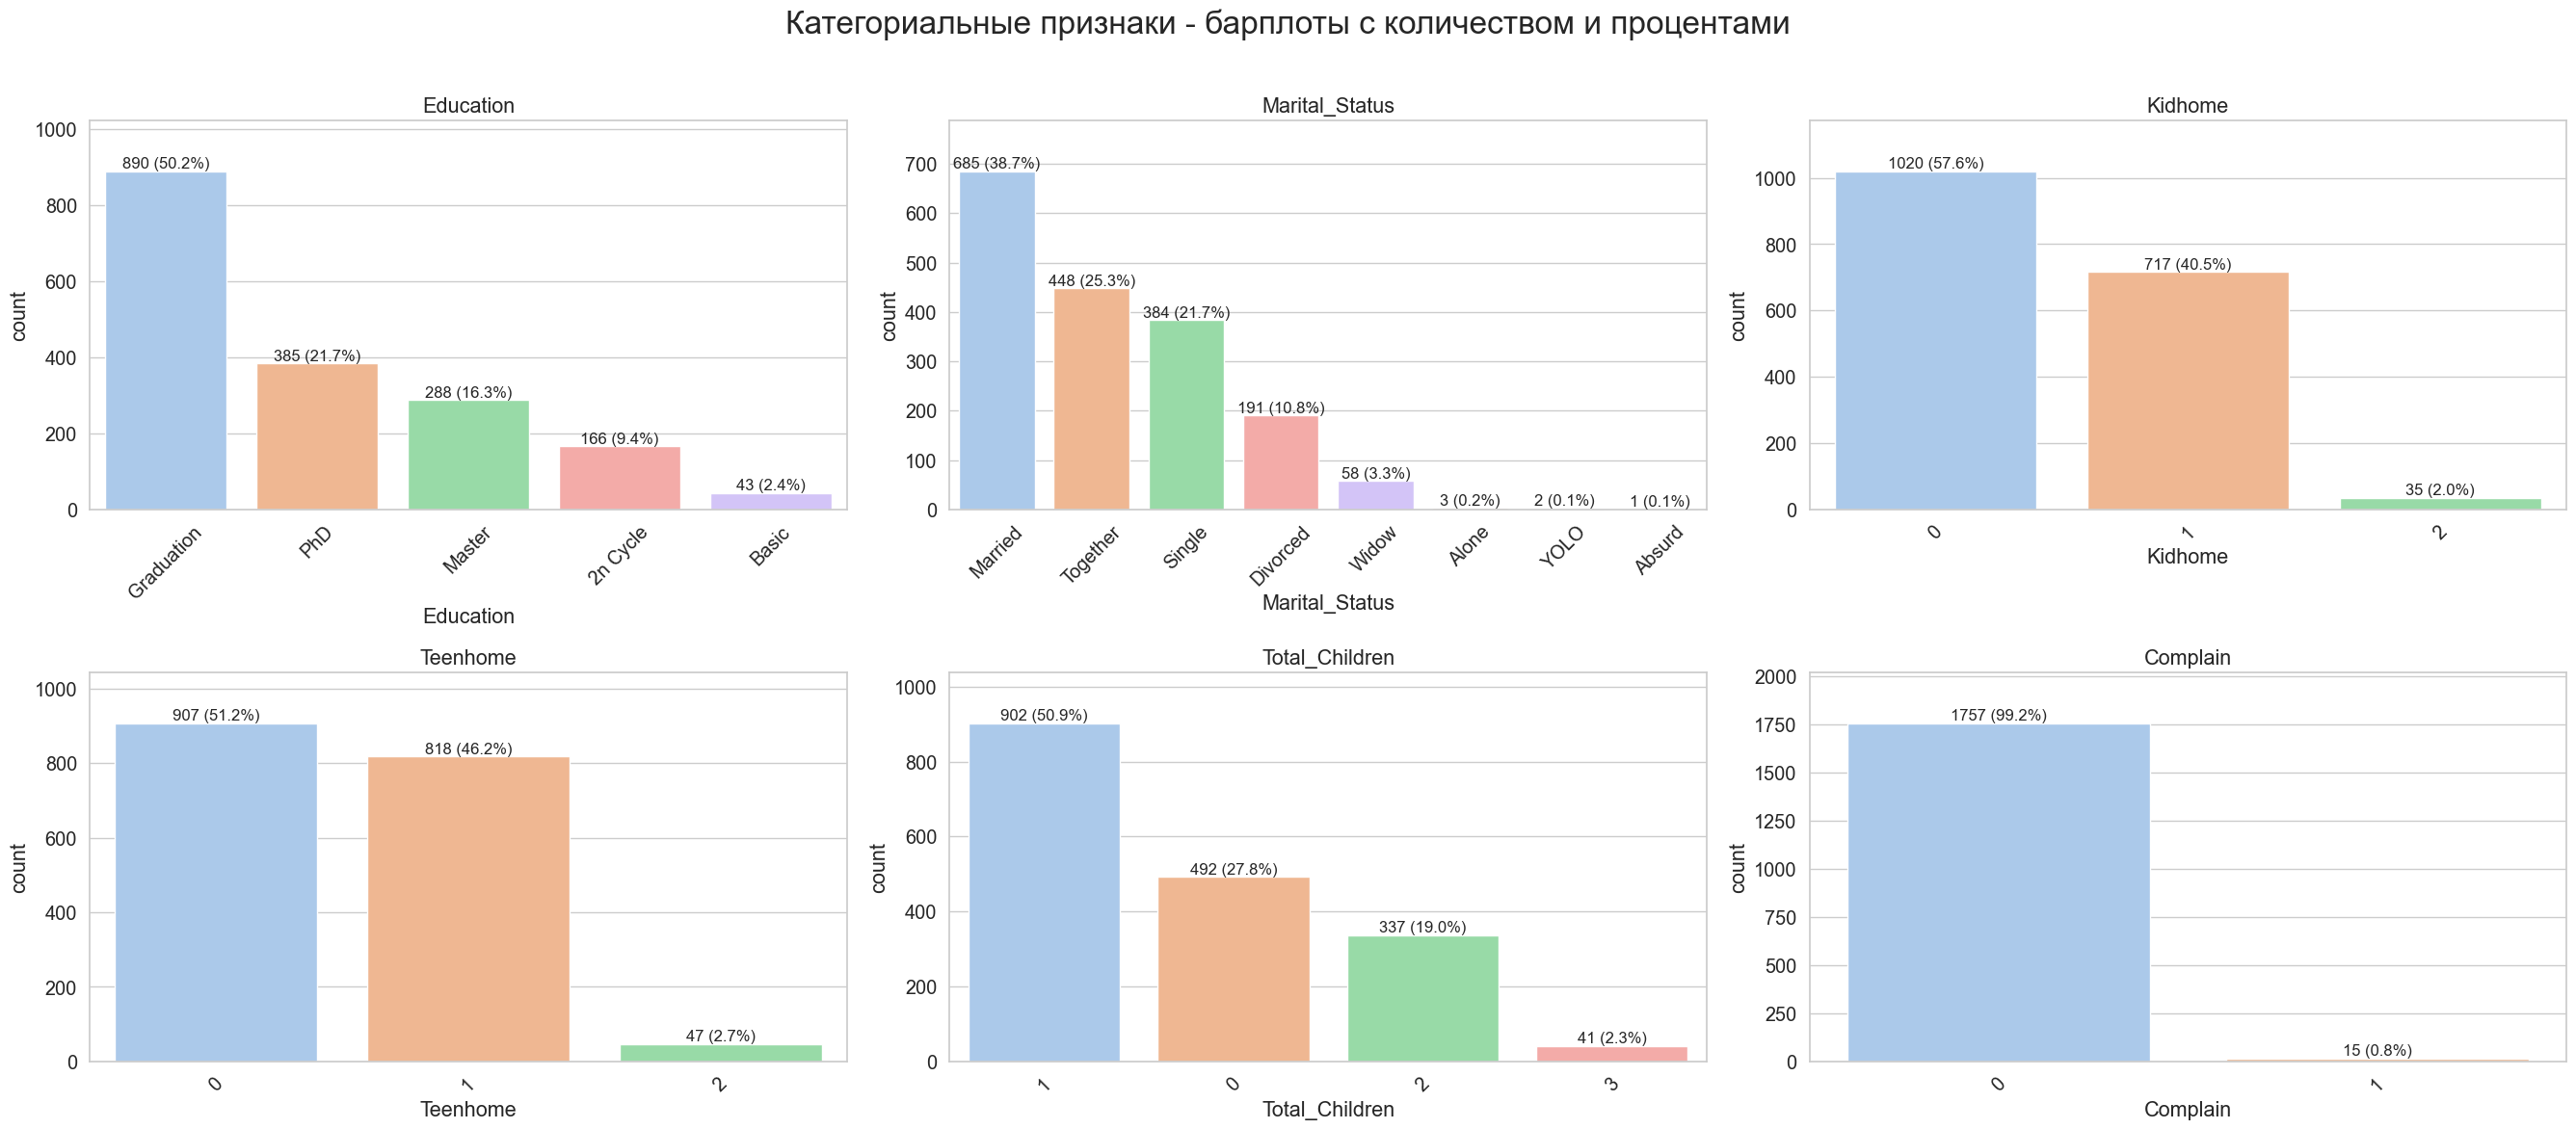

In [10]:
n_cat = len(cat_columns)
cols = 3
rows = math.ceil(n_cat / cols)

fig_cat, axes_cat = plt.subplots(rows, cols, figsize=(cols * 9, rows * 6))
axes_cat = axes_cat.flatten()

for i, col in enumerate(cat_columns):
    ax = axes_cat[i]
    order = X_train[col].value_counts().index  # Чтобы порядок был по убыванию
    counts = X_train[col].value_counts()
    total = len(X_train)

    sns.countplot(data=X_train, x=col, ax=ax, order=order, palette="pastel", legend=False)
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=45)

    for p in ax.patches:
        count = int(p.get_height())
        percent = 100 * count / total
        ax.annotate(
            f"{count} ({percent:.1f}%)",
            (p.get_x() + p.get_width() / 2.0, p.get_height()),
            ha="center",
            va="bottom",
            fontsize=12,
        )
    ax.set_ylim(0, max(counts.values) * 1.15)

# Удаляем лишние оси
for j in range(i + 1, len(axes_cat)):
    fig_cat.delaxes(axes_cat[j])

fig_cat.suptitle("Категориальные признаки - барплоты с количеством и процентами", fontsize=24)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

&#x2753; **Вопрос** &#x2753;

> Что можно сказать по этим графикам?

<details>
 <summary> Открыть объяснение </summary>

* Большинство имеют высшее образование, магистров и кандидатов больше трети.

* Больше половины состоят в отношениях

* Половина семей имеет одного ребенка, меньше трети — без детей

* На предыдущую кампанию откликнулось 15%, что неплохой показатель для рекламной кампании, возможно на следующую тоже ответят хорошо

* Менее одного процента жаловались на магазин, значит покупатели в целом всем довольны.
</details><br/>

Что можно изменить в этих данных и на какие мысли они нас могут натолкнуть?

* В `Education` категории `Basic` и `2n Cycle` довольно экзотичные — кандидаты на исключение или объединение.
* В `Marital Status` категории `Single` и `Alone` — взаимозаменяемые, можно объединить, а `YOLO` и `Absurd` можно исключить, так как нет понимания, что это, а их количество очень маленькое.


Нет необходимости хранить в датасете классы количеством объектов 1-2-3, это не поможет нашим предсказаниям, наоборот только усложнит задачу.


А что с образованием? После небольшого ресерча в гугле можно прийти к выводу, что `Basic` это старшая или средняя школа, а `2n Cycle` это магистратура. Поэтому совместим эти категории, чтобы не усложнять нашей модели задачу по использованию малых категорий


In [11]:
# Объединяем категории и чистим train
X_train["Marital_Status"] = X_train["Marital_Status"].replace({"Alone": "Single"})
X_train = X_train[~X_train["Marital_Status"].isin(["YOLO", "Absurd"])].copy()

X_train["Education"] = X_train["Education"].replace({"2n Cycle": "Masters", "Basic": "Graduation"})

# Не забываем про столбец таргета
y_train = y_train.loc[X_train.index]

# Объединяем категории и чистим test
X_test["Marital_Status"] = X_test["Marital_Status"].replace({"Alone": "Single"})
X_test = X_test[~X_test["Marital_Status"].isin(["YOLO", "Absurd"])].copy()

X_test["Education"] = X_test["Education"].replace({"2n Cycle": "Masters", "Basic": "Graduation"})

y_test = y_test.loc[X_test.index]

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(1769, 20) (1769,)
(443, 20) (443,)


До очистки датасета у нас было 1772 объектов в обучающей выборке и  444 в тестовой, в сумме мы убрали 4 объекта.

Мы убрали неугодные данные, их совсем немного, поэтому вполне уместно, продолжаем.

#### 2.5. Работа с числовыми данными

Возьмем признак `Income` и визуализируем несколькими способами.

**Методы визуализации распределения**

---

**Гистограмма** (`histplot`)

Гистограмма показывает, **как часто встречаются значения** в разных диапазонах.  
Полезна для понимания формы распределения, особенно при больших объёмах данных. Гистограммы — простой и наглядный способ, в котором хорошо будет видно моду (самое частое значение) и примерное распределение полученных данных

Но она довольно чувствительна к количеству бинов (`bins`) и не показывают гладкое распределение.

**Параметры `sns.histplot()`:**
- `data` — выборка данных
- `bins` — количество интервалов
- `kde` — добавить ли KDE-график (`True/False`)
- `stat` — `'count'`, `'density'`, `'probability'`
- `color`, `edgecolor`, `alpha` — внешний вид



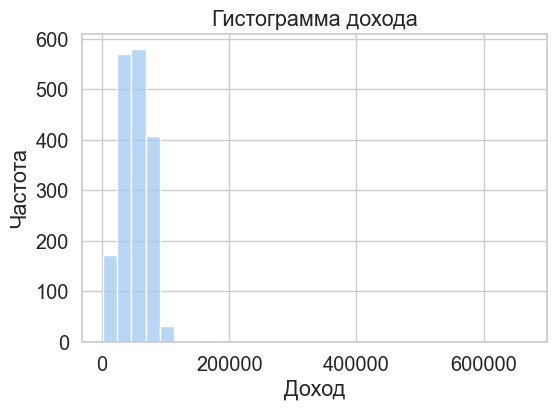

In [12]:
plt.figure(figsize=(6, 4))
sns.histplot(X_train["Income"], bins=30)
plt.title("Гистограмма дохода")
plt.xlabel("Доход")
plt.ylabel("Частота")
plt.show()

> **Ядерная оценка плотности**
>
>Плавная оценка распределения, без резких столбиков.  
Хорошо показывает форму, пики и хвосты, но может быть неустойчива к выбросам.
>
>Пусть $X = (X_1, ..., X_n)$ &mdash; выборка из непрерывного распределения.
Выберем
>* $q(x)$ &mdash; некоторая "базовая" плотность, называемая **ядром**. Чаще всего в качестве ядра рассматривают плотность нормального распределения $\mathcal{N}(0, I_n)$.
>* $h > 0$ &mdash; величина, отвечающая за масштабирование ядра, называемая **шириной ядра**.
>
>Тогда **ядерной оценкой плотности** (kernel density estimation, KDE) по выборке $X$ называется плотность
$$\widehat{p}_h(x) = \frac{1}{nh}\sum_{i=1}^n q\left(\frac{x-X_i}{h}\right).$$
>
>**Смысл:** в каждую точку выборки поставили отмасштабированное ядро так, будто эта точка — центр ядра, а затем усреднили значения соседних точек с весами, заданными этим ядром. Вместо тысячи слов — [интерактивная иллюстрация](https://mathisonian.github.io/kde/).
>
>
>Ядерные оценки плотности — KDE, Kernel Density Estimates — способ что-то понять о распределении, когда неизвестно ничего. Такого рода методы называют **непараметрическими**, они иллюстрируют разницу подходов в статистике и теории вероятностей: если в теории вероятности известно распределение и исследуются его свойства, то в статистике зачастую известны только данные, и по их свойствам угадывается распределение.
>
>


> 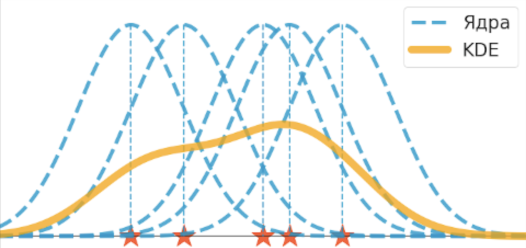

<details>
<summary>Технические детали (кликни для показа)</summary>

Можно воспользоваться функциями:

- `sns.histplot()` — гистограмма и KDE
- `sns.kdeplot()` — только KDE
- `sns.rugplot()` — отдельный rug (штрихи)
- `scipy.stats` — для наложения теоретической плотности

---

`sns.histplot()`

* `data` — данные, которые визуализируются (например, `X_train['Income']`)
* `bins` — количество интервалов (по умолчанию выбирается автоматически)
* `kde` — добавить ли ядерную оценку плотности (`True/False`)
* `stat` — тип значения на оси Y: `'count'`, `'frequency'`, `'density'`, `'probability'`
* `color` — цвет столбиков
* `edgecolor` — цвет границ столбиков
* `alpha` — прозрачность (от `0.0` до `1.0`)
* `multiple` — наложение или группировка (`'stack'`, `'dodge'`, `'fill'`)

---

`sns.kdeplot()`

* `data` — данные для оценки плотности
* `fill` — закрашивать ли под кривой (`True/False`)
* `bw_adjust` — ширина окна сглаживания (больше → более гладкая кривая)
* `color` — цвет линии
* `label` — подпись в легенде
* `linewidth` — толщина линии

---

`sns.rugplot()`

* `data` — данные, где рисовать "штрихи"
* `height` — высота штрихов
* `color` — цвет
* `alpha` — прозрачность


</details>


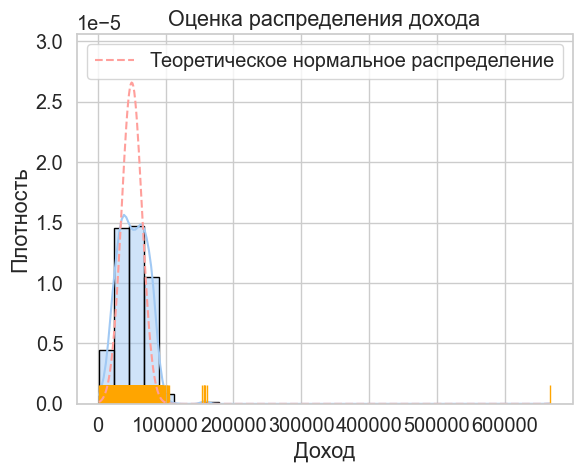

In [13]:
# Гистограмма и KDE (фиолетовый цвет для KDE)
sns.histplot(data["Income"], bins=30, stat="density", kde=True, edgecolor="black")

# Rugplot (оранжевый цвет)
sns.rugplot(X_train["Income"], color="orange", height=0.05)

# Теоретическая плотность нормального распределения
mu_theoretical = 50000
sigma_theoretical = 15000

xmin, xmax = X_train["Income"].min(), data["Income"].max()
x = np.linspace(xmin, xmax, 500)
pdf_theoretical = sps.norm.pdf(x, mu_theoretical, sigma_theoretical)

plt.plot(x, pdf_theoretical, "r--", label="Теоретическое нормальное распределение")
plt.title("Оценка распределения дохода")
plt.xlabel("Доход")
plt.ylabel("Плотность")
plt.legend()
plt.show()

&#x2753; **Вопрос** &#x2753;

> Чем такой подход полезен в аналитике?

<details> <summary> Ответ </summary>

В отличие от гистограмм и боксплотов показывает гладкую кривую плотности, которая поможет увидеть моду(пик) и мультимодальность, асимметрию, хвосты, как похоже на теоретическое распределение.

Помогает увидеть более детальную структуру. Гистограмма грубо режется на бины. + гистограмма показывает только существующие данные, КДЕ их "аппроксимирует" и заполняет пропускими с помощью своих теоретических ядер

Визуально гораздо более приятно накладывать несколько КДЕ кривых, нежели гистограмм.
</details>

Стоит учитывать, что при ограниченных распределениях метод kNN может давать некорректные оценки плотности на границах. Например, для признака «возраст» сглаживание способно сместить часть массы распределения в недопустимую область (меньше нуля), что снижает достоверность результатов.

Теперь можем посмотреть на все наши признаки:

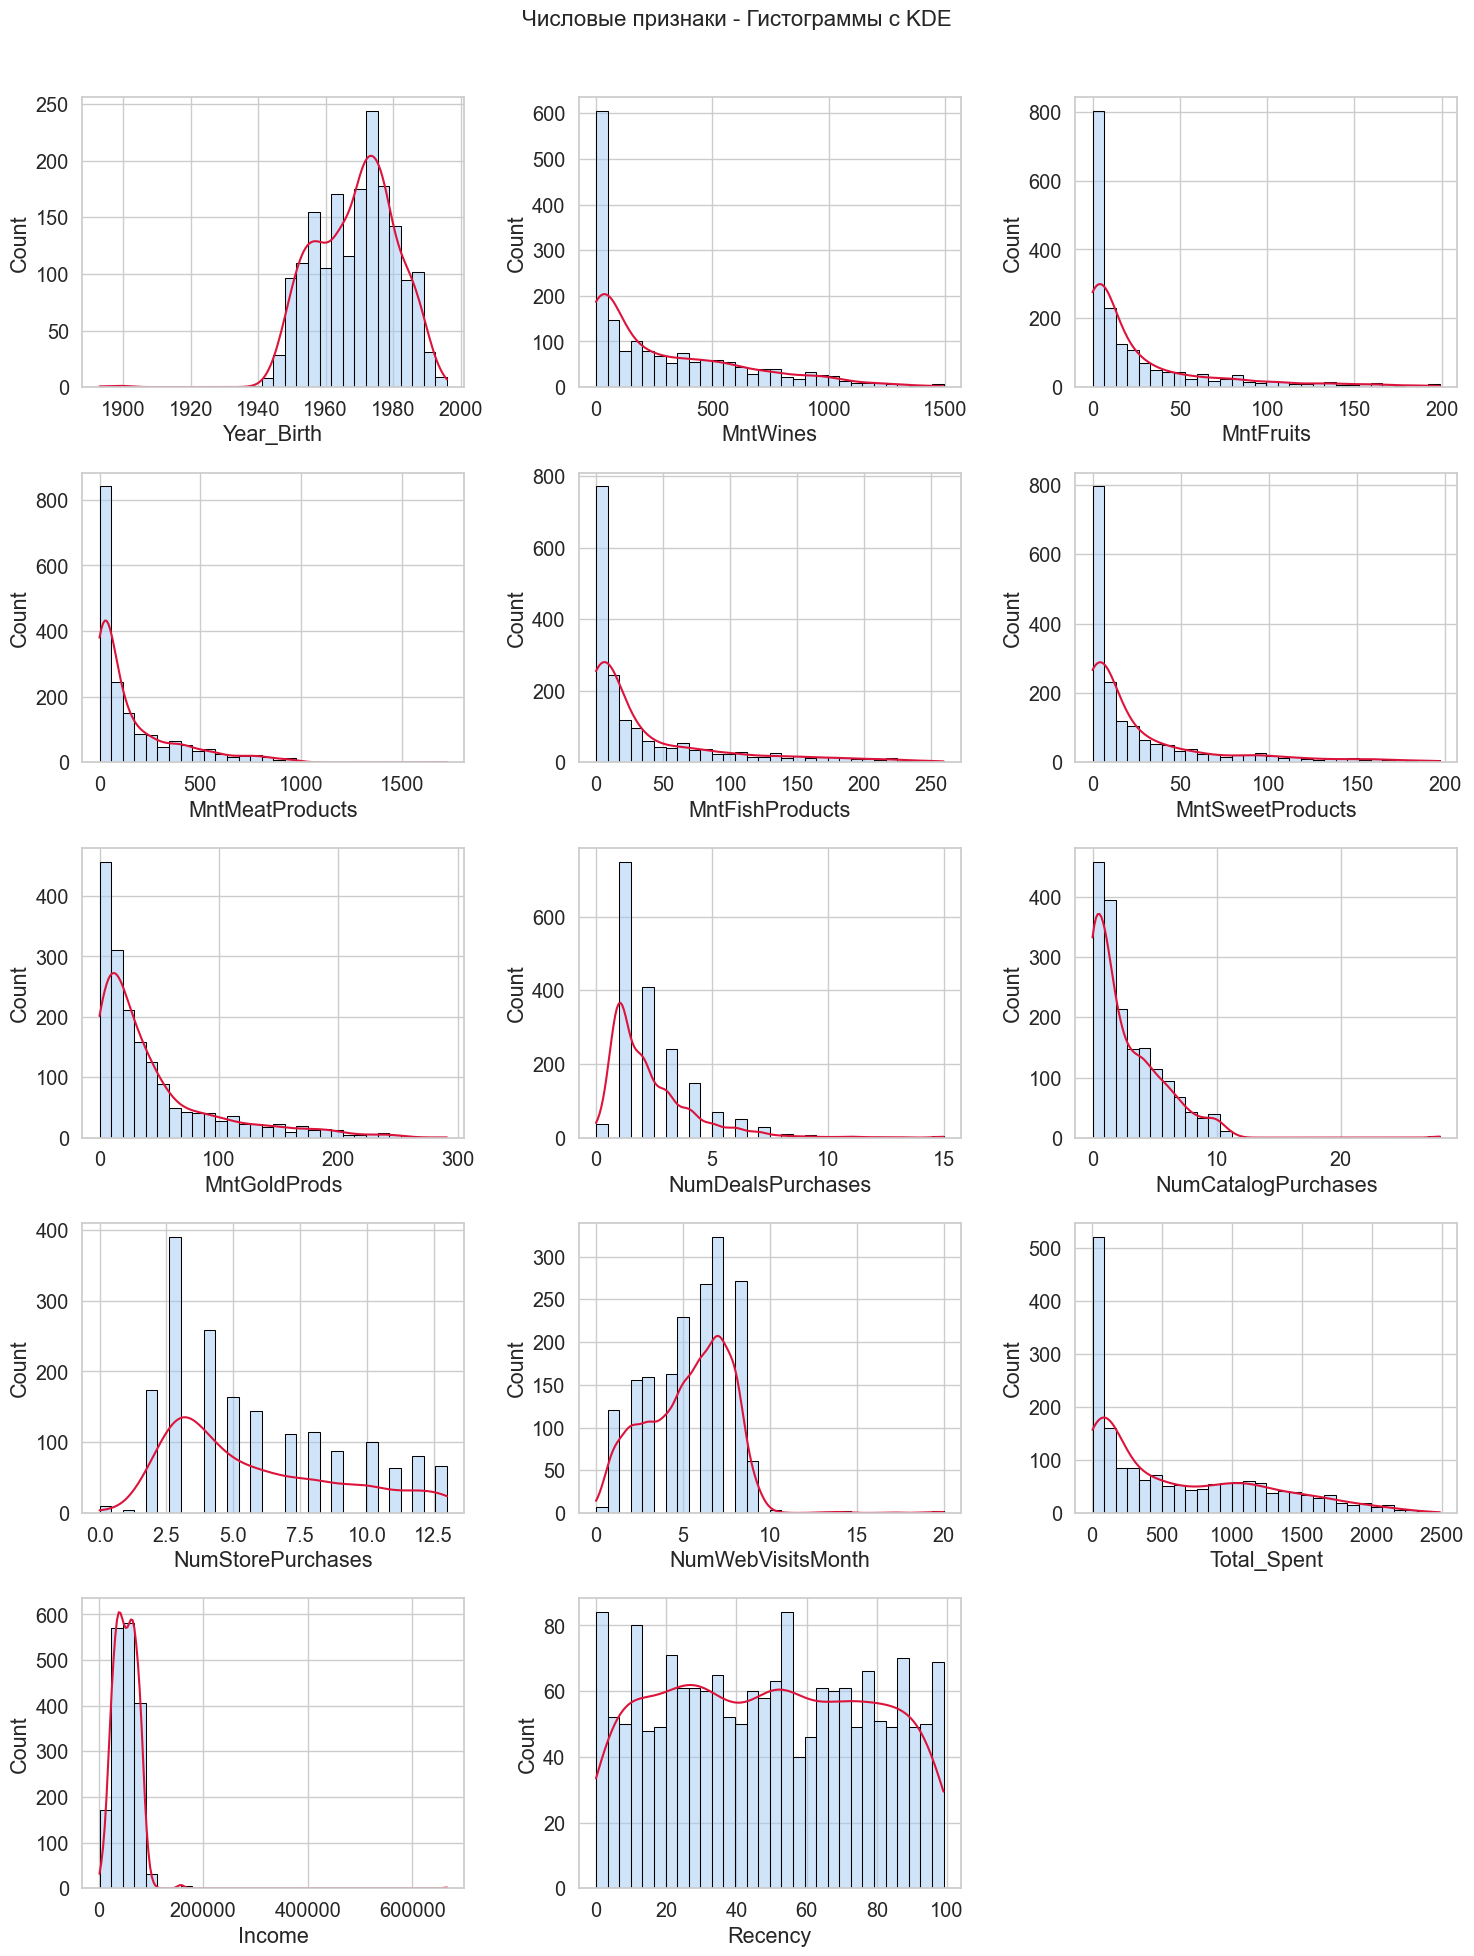

In [14]:
n_num = len(num_columns)
cols = 3
rows = math.ceil(n_num / cols)

fig_hist, axes_hist = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4))
axes_hist = axes_hist.flatten()

for i, col in enumerate(num_columns):
    ax = axes_hist[i]
    sns.histplot(X_train[col], kde=True, ax=ax, edgecolor="black", bins=30)
    kde_line = ax.lines[0]
    kde_line.set_color("crimson")

for j in range(i + 1, len(axes_hist)):
    fig_hist.delaxes(axes_hist[j])

fig_hist.suptitle("Числовые признаки - Гистограммы с KDE", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

В некоторых признаках количество уникальных значений очень мало. Для таких случаев более информативно использовать не обычные гистограммы, а барплоты или гистограммы с настройкой бинов.


Мы можем построить распределения так, чтобы бины были центрированы на целых числах и соответствовали количеству возможных значений признака. Это позволит наглядно сравнить частоты и дополнительно оценить форму распределения с помощью KDE.


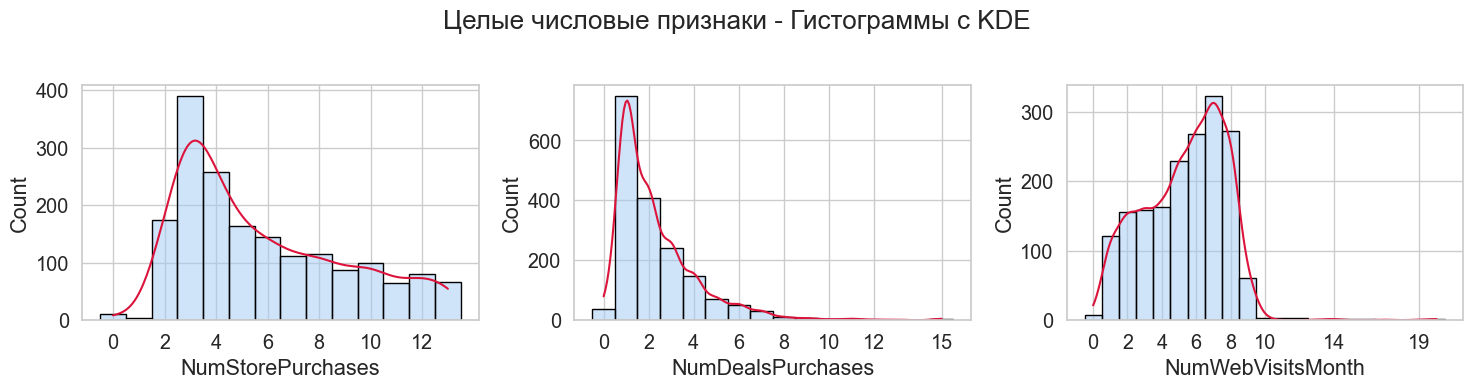

In [15]:
bar_columns = ["NumStorePurchases", "NumDealsPurchases", "NumWebVisitsMonth"]

n_num = len(bar_columns)
cols = 3
rows = math.ceil(n_num / cols)

fig_hist, axes_hist = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4))
axes_hist = axes_hist.flatten()

for i, col in enumerate(bar_columns):
    ax = axes_hist[i]
    unique_vals = sorted(X_train[col].dropna().unique())  # получаем уникальные значения
    sns.histplot(
        X_train[col],
        kde=True,
        bins=[x - 0.5 for x in unique_vals]
        + [unique_vals[-1] + 0.5],  # бин вокруг каждой целой точки
        ax=ax,
        edgecolor="black",
    )
    if len(unique_vals) > 10:  # отображаем только каждый второй тик
        ax.set_xticks(unique_vals[::2])  # чтобы тики совпадали с целыми
    kde_line = ax.lines[0]
    kde_line.set_color("crimson")

for j in range(i + 1, len(axes_hist)):
    fig_hist.delaxes(axes_hist[j])

fig_hist.suptitle("Целые числовые признаки - Гистограммы с KDE")
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()



Нет абсурдных данных (например, с отрицательными тратами), это хорошо (хотя у нас есть люди, которым больше 100 лет и они были в магазине 30 дней назад🫠).


&#x2753; **Вопрос** &#x2753;

> Мы видим, что в данных много выбросов. Надо ли их убирать? В каких признаках?


<details>
 <summary> Кликни для показа ответа </summary>

Выбросы — это значения, которые значительно отличаются от основной массы данных.

Много выбросов:
* **Income** — очень сильный выброс (>600,000)
* **Total_Spent** — заметный выброс справа
* **MntWines, MntMeatProducts, MntGoldProds** — длинные хвосты и экстремальные значения

Некоторые выбросы:

* **NumCatalogPurchases, NumDealsPurchases, NumWebVisitsMonth**

*Убирать или не убирать?*

Если есть надежный способ проверить, что эти значения ошибочные — да.

Ответ всегда зависит от задачи. С одной стороны, выбросы могут исказить наши тренды, среднее, медианы, корреляции. С другой — могут быть важными контрибьюторами.

Если мы применяем методы или метрики, чувствительные к таким выбросам, то их надо либо удалить, либо выбрать устойчивые способы анализа.

</details><br/>

In [16]:
# Dt_Customer - последний день визита в магазин
data[data.Year_Birth == min(data["Year_Birth"])][["Year_Birth", "Dt_Customer"]]

,Year_Birth,Dt_Customer
513,1893,2014-05-17


😳😳😳😳

В жизни, если в ваших данных вы видите абсурдные данные, есть два пути:

- убрать их самостоятельно, пользуясь собственным здравым смыслом и логикой

- и пойти к ответственному за данные и попросить его разобратьс, что не так с этими данными, почему в них оказались такие странные значения. Возможно вскроется ошибка, которую вы помогли исправить, а возможно так и должно быть

В нашем случае следует убрать, так как возможности уточнить у кого-то, почему так - у нас нет.

In [17]:
# Убираем всех, кто родился до 1914 года
X_train = X_train[X_train["Year_Birth"] >= 1914].copy()
y_train = y_train.loc[X_train.index]

X_test = X_test[X_test["Year_Birth"] >= 1914].copy()
y_test = y_test.loc[X_test.index]

print(X_train.shape, X_test.shape)

(1766, 20) (443, 20)


**Немного про корреляционный анализ**

>**Коэффициент корреляции Пирсона**
>
>Классическая метрика линейной зависимости между двумя переменными:
>
>$$r = \frac{\mathrm{cov}(X, Y)}{\sqrt{\mathsf{D}X \mathsf{D}Y}}$$
>
>
>- Значение $r$ лежит в интервале $[-1, 1]$
>- $r > 0$ — прямая связь, $r < 0$ — обратная
>- Улавливает **только линейные зависимости**
>- Используется по умолчанию в `df.corr()` в pandas и seaborn

---

**Heatmap**

- `sns.heatmap()` — просто рисует значения корреляции между переменными в виде матрицы

- Оба по умолчанию используют **коэффициент Пирсона**, если явно не задать иначе

---


- Для числовых признаков с нормальным распределением и линейной зависимостью лучше Пирсон.
- С бинарными признаками тоже можно считать Пирсона, но лучше помнить, что он показывает разницу средних между группами.



`seaborn.clustermap()` &mdash; это расширенная версия тепловой карты, которая автоматически группирует похожие строки и/или столбцы, что помогает находить структуру в данных и выделять группы объектов.

Основные параметры (дополняющие стандартные параметры heatmap):

```
seaborn.clustermap(
    X_train, pivot_kws=None, method='average', metric='euclidean', z_score=None,
    standard_scale=None, figsize=(10, 10), row_cluster=True, col_cluster=True,
    row_colors=None, col_colors=None, mask=None, dendrogram_ratio=0.2, **kwargs
)

```

У функции очень много технических параметров, так что рассмотрим только основные из тех, которых нет среди параметров `heatmap`:

- `data` — 2D-данные;
- `row_cluster`, `col_cluster` — группировать ли строки или столбцы соотв-но;
- `row_colors`, `col_colors` — цветовые метки отдельных строк и столбцов (позволяет следить за их порядком);
- `method` — метод группировки ([см. документацию к иерархической кластеризации](https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.linkage.html) в scipy);
- `mask` — позволяет указать, какие значения в таблице не показывать (по умолчанию скрываются только пропуски);
- `z_score` — привести ли все строки (если 0) или столбцы (если 1) к одному масштабу `((x - mean(x)) / std(x))`;
- `standard_scale` — перевести ли все строки (если 0) или столбцы (если 1) в диапазон [0, 1] `((x - min(x)) / (max(x) - min(x)))`;


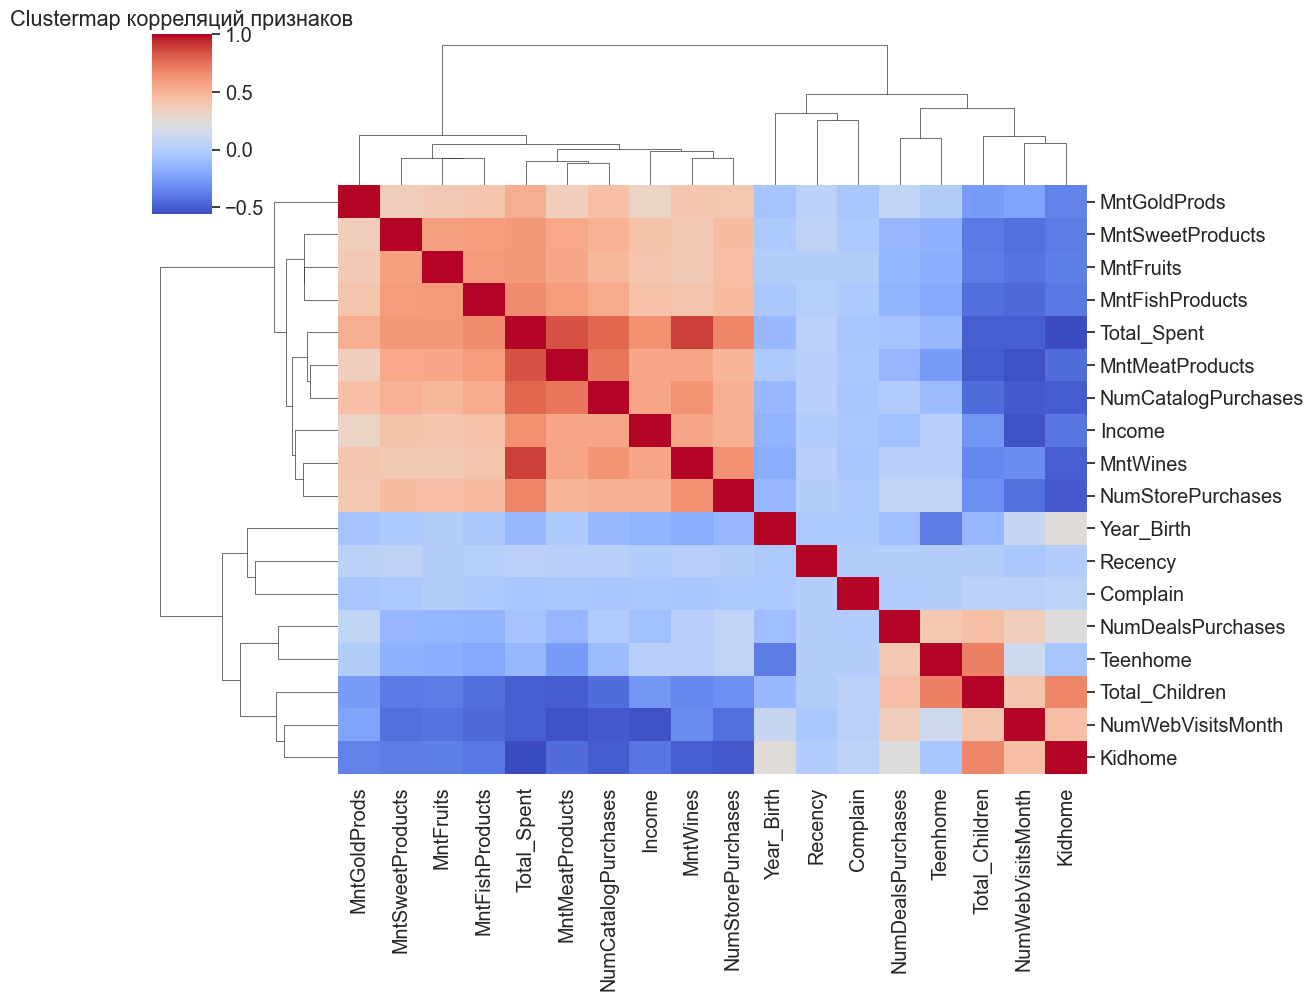

In [18]:
sns.clustermap(X_train.corr(numeric_only=True), cmap="coolwarm", annot=False, figsize=(12, 10))
plt.title("Clustermap корреляций признаков")
plt.show()

***Выводы о данных:***



- С `Response` коррелируют `MntWines` (количество купленного вина), `MntMeatProducts` (количество мясных продуктов), `NumCatalogPurchases` (количество покупок из каталога)


- Видим кластер `Teenhome`, `NumDealsPurchases`, `Total_Children`. Прошлая визуализация нам показала похожие выводы: семьи с детьми чаще покупают товары со скидкой

- Большой кластер `Income`, `Total_Spent` и все `Mnt...` коррелирует — это достаточно логично: человек тратит деньги, только если есть, что потратить






В машинном обучении сильно коррелирующие признаки могут доставить проблемы: добавление шума, нестабильность предсказаний и переобучение. Что как и почему - вы узнаете дальше, но пока надо запомнить, что проверять данные на корреляции нужно.



Мы посмотрели на основные методы визуализации и анализа данных на одном из каггловских датасетов. Очистили и привели данные к удобному нам виду и нарисовали много красивых графиков.

Получили некоторые выводы из наших данных, которые возможно помогут магазину сделать таргетированную рассылку.

- Выявлены ключевые зависимости: дети, доход, частота покупок, выявлены активные и прибыльные сегменты

- Основываясь на наших выводах, можно рекомендовать бизнесу клиентов для таргетированной рассылки: высокодоходные (конечно), частые покупатели, клиенты без детей, любители вина и мяса 😁

- Подгтовили почву для более глубокого анализа и моделирования (EDA это всегда первй шаг для ML)

- Полученные знания помогут нам интерпретировать результаты модели для бизнеса

Теперь можем перейти к более осознанному МЛ.

### 3. Построение ML-моделей

Будем предсказывать целевую переменную `Response`, по нашим данным. В признаках оставим только числовые переменные.
Выделим отдельно признаки и таргет.

 **Признаки (Features)** &mdash; `X`
 - Это входные переменные/атрибуты, которые используются для предсказания

*В нашей задаче* в качестве признаков выступают данные о покупках клиента за прошлый год, что показывает его поведение.

 **Таргет (Target)** &mdash; `y`
 - Это выходная переменная, которую мы хотим предсказать

*В нашей задаче* в качестве таргета выступает решение клиета принять предложение или нет (`1/0`)


Возьмем из наших данных только числовые признаки, с категориальными мы научимся работать чуть позже

Посмотрим на размерность признаков.

In [19]:
X_train.shape, X_test.shape

((1766, 20), (443, 20))

In [20]:
# Проверяем размеры выборок
print(f"Размер тренировочной выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")
print(f"Доля положительных откликов в трейне: {y_train.mean():.3f}")
print(f"Доля положительных откликов в тесте: {y_test.mean():.3f}")

Размер тренировочной выборки: (1766, 20)
Размер тестовой выборки: (443, 20)
Доля положительных откликов в трейне: 0.149
Доля положительных откликов в тесте: 0.151


Как мы видим, в обучающей выборке у нас 1766 объектов, а в тестовой - 443, в обеих выборках - 20 признаков.

Напомним как разделить датасет на 2 набора данных: тренировочный и тестовый.

Для этого воспользуемся функцией [train_test_split](https://scikit-learn.org/dev/modules/generated/sklearn.model_selection.train_test_split.html) из модуля `sklearn.model_selection`.


> &#x2757; **Важно:** При обучении модель ничего не должна знать о тестовой выборке.

Как мы могли заметить классы таргета не сбалансированны. Это может привести к серьезым проблемам при разбиение данных. Например в тестовой выборке будет только один класс таргета. Для решения данной проблемы в `train_test_split` есть параметр `stratify`. При вводе `stratify = y` разбиение сохранит пропорции классов как в исходной выборке.


KNN ищет ближайших соседей по расстоянию (обычно евклидовому).

Если в данных есть категориальные признаки (Yes/No, Red/Blue/Green и т. д.), модель не понимает, как считать расстояние между строками.


One-Hot Encoding переводит категории в набор бинарных фичей (0/1), и тогда KNN может считать расстояния нормально.
Если этого не сделать, то KNN упадёт с ошибкой, потому что не может считать расстояния между строками.

Подробнее об преобразованиях вы узнаете позже

In [21]:
# создаём энкодер
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

# обучаем на train и трансформируем train/test
X_train_ohe = ohe.fit_transform(X_train[cat_columns])
X_test_ohe = ohe.transform(X_test[cat_columns])

# получаем названия новых признаков
ohe_columns = ohe.get_feature_names_out(cat_columns)

# превращаем обратно в DataFrame
X_train_ohe = pd.DataFrame(X_train_ohe, columns=ohe_columns, index=X_train.index)
X_test_ohe = pd.DataFrame(X_test_ohe, columns=ohe_columns, index=X_test.index)

# выделяем числовые признаки
num_features = [col for col in X_train.columns if col not in cat_columns]

# объединяем обратно
X_train = pd.concat([X_train[num_features], X_train_ohe], axis=1)
X_test = pd.concat([X_test[num_features], X_test_ohe], axis=1)

print(X_train.shape, X_test.shape)

(1766, 35) (443, 35)


Перед началом обучения и предсказания, сделаем лидерборд наших моделей

In [22]:
df_score = pd.DataFrame(columns=["model", "score"])

#### 3.1. Базовый классификатор (DummyClassifier)

Прежде чем оценивать сложные модели, полезно установить базовый уровень точности, который должен быть превзойден. Для этого используется "фиктивный" классификатор &mdash; `DummyClassifier`. Готовая [реализация](https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyClassifier.html) этой модели есть в sklearn-е в модуле `sklearn.dummy`.

Создадим экземпляр классификатора:

- `strategy`: стратегия генерации "предсказаний". Основные варианты:
  - `"most_frequent"`: всегда предсказывает самый частый класс в обучающих данных.
  - `"stratified"`: делает случайные предсказания, сохраняя распределение классов обучающей выборки.
  - `"uniform"`: делает случайные равномерные предсказания.
  - `"constant"`: всегда предсказывает заданный пользователем класс (параметр `constant`).

Выберем стратегию `strategy = "most_frequent"`, чтобы установить базовый уровень по самому частому классу.

&#x2753; **Вопрос** &#x2753;

> Почему важно использовать `DummyClassifier` перед обучением настоящей модели и на что может указать его высокая точность?

<details>
  <summary> Кликни для показа ответа </summary>
  
> `DummyClassifier` служит контрольной точкой (baseline) для оценки качества реальных моделей. Если ваша сложная модель показывает точность ненамного выше, чем `DummyClassifier`, это может означать, что:
> 1.  **Задача слишком проста** и даже наивная стратегия дает хороший результат.
> 2.  **Модель работает плохо** и не выявляет закономерностей в данных.
> 3.  **Данные несбалансированы**. Если один класс сильно доминирует (напр., 90% объектов одного класса), то стратегия `"most_frequent"` сразу даст 90% точность. Высокая точность dummy-модели в этом случае указывает на необходимость использования других метрик (например, F1-score, precision, recall) для адекватной оценки моделей.
> 4.  **Признаки не несут полезной информации** для предсказания целевой переменной.

</details><br/>




Обучим базовую модель на самый частый класс.

In [23]:
const_model = DummyClassifier(strategy="most_frequent")

Для обучения *любой* модели в sklearn-е используется метод класса  `fit(X_train, y_train)`.


In [24]:
const_model.fit(X_train, y_train)

,strategy,'most_frequent'
,random_state,None
,constant,None


❓ Вопрос ❓

>Что метод fit сделал в данном случае?

<details> <summary> Кликни для показа ответа </summary>

Метод `fit` для `DummyClassifier` со стратегией "most_frequent" выполнил следующие действия:

* Проанализировал целевую переменную `y_train` (метки классов обучающей выборки)

* Рассчитал распределение классов - определил, какой класс встречается чаще всего

* Запомнил самый частый класс - сохранил его как константу для будущих предсказаний

* Игнорировал признаки `X_train` - в отличие от "настоящих" моделей, фиктивный классификатор не изучает взаимосвязи между признаками и целевой переменной

Пример: Если в `y_train` 70% образцов принадлежат классу "A", 20% - классу "B" и 10% - классу "C", то после вызова `fit()` модель будет всегда предсказывать класс "A" независимо от входных данных.


</details><br/>

Теперь когда мы обучили модель, мы можем использовать ее для получения предсказаний. Для этого аналогично обучению существует метод `model.predict(X_test) `


In [25]:
y_pred_baseline = const_model.predict(X_test)

❓ Вопрос ❓

>Что метод predict сделал в данном случае?

<details> <summary> Кликни для показа ответа </summary>

Метод `predict` для `DummyClassifier` со стратегией "most_frequent" выполнил следующие действия:

* Полностью проигнорировал входные данные `X_test` - не анализировал признаки тестовых образцов

* Вернул массив предсказаний, где каждое предсказание равно самому частому классу из обучающей выборки

* Создал массив одинаковых предсказаний - все элементы массива `predictions` будут иметь одинаковое значение

Пример: Если при обучении был определен класс "A" как самый частый, то для любого набора данных X_test метод вернет массив `["A", "A", "A", ..., "A"]` той же длины, что и `X_test`.


</details><br/>

Посмотрим на результат предсказания.

In [26]:
y_pred_baseline.shape, y_pred_baseline[:15]

((443,), array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]))

Как видим предсказания представляют собой массив из одного самого популярного класса в нашем случае `0`.

Оценим качество нашей модели по метрике *accuracy*.

In [27]:
score_baseline = accuracy_score(y_test, y_pred_baseline)
df_score.loc[len(df_score)] = ["Dummy (most_frequent)", score_baseline]
print(f"метрика accuracy = {score_baseline*100:.2f}%")

метрика accuracy = 84.88%


Таким образом мы получили некоторый бейзлайн для дальнейшего обучения более сложных моделей.

#### 3.2. Ручное правило подбора

Мы заметили, что распределения признаков сильно зависят от класса. Это наводит на мысль: можно попытаться построить простое эвристическое правило классификации, которое решает задачу без сложных алгоритмов.

**Идея:** выбрать пороговое значение (threshold) для признака и сказать:

- если признак меньше порога → объект относится к классу A,

- если больше или равен → к классу B.

Такое правило — это по сути одномерный классификатор по признаку.
Если же задать несколько последовательных условий (например, сначала разделить по одному признаку, потом внутри каждой ветви — по другому), то получится ручное дерево решений. Оно отражает интуицию исследователя о том, какие признаки лучше всего отделяют классы.

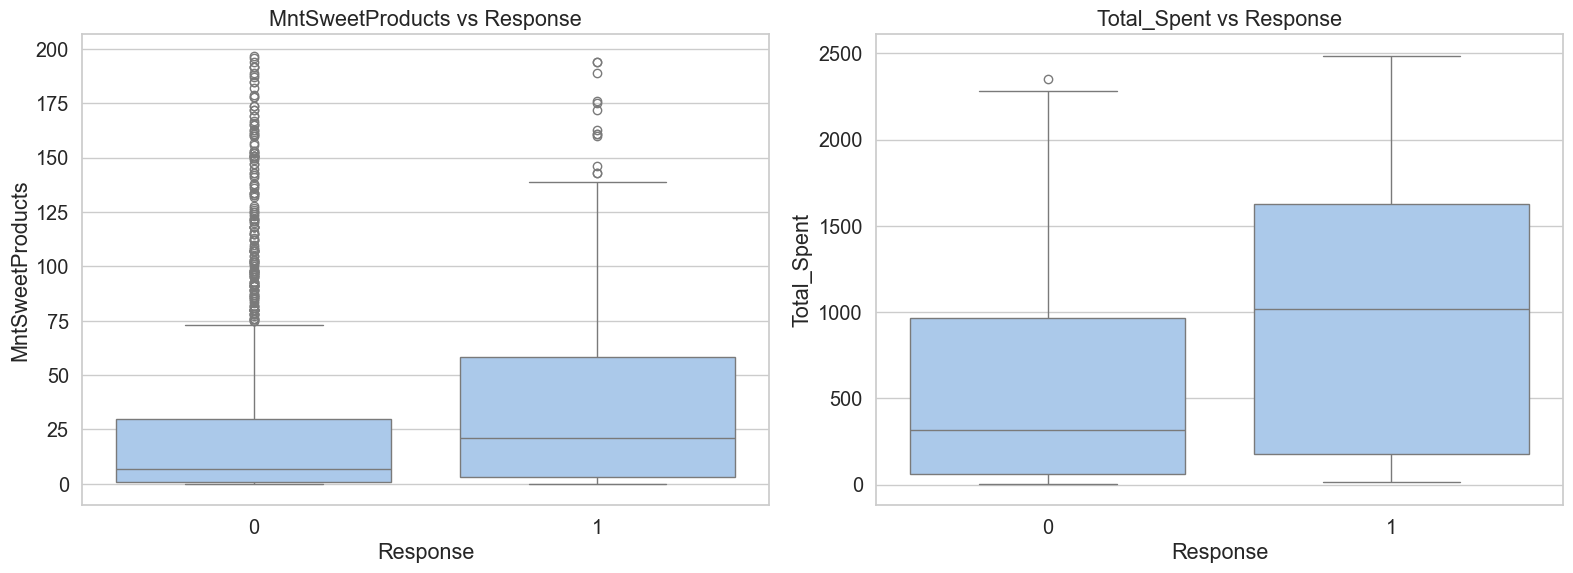

Выбран порог для MntSweetProducts: 8.0
Выбран порог для Total_Spent: 396.0


In [28]:
feature1 = "MntSweetProducts"  # Количество купленных сладостей
feature2 = "Total_Spent"  # Потраченная сумма

fig, axes = plt.subplots(1, 2, figsize=(16, 6))  # 1 строка, 2 колонки

sns.boxplot(x=y_train, y=X_train[feature1], ax=axes[0])
axes[0].set_title(f"{feature1} vs Response")

sns.boxplot(x=y_train, y=X_train[feature2], ax=axes[1])
axes[1].set_title(f"{feature2} vs Response")

plt.tight_layout()
plt.show()

threshold1 = X_train[feature1].median()
threshold2 = X_train[feature2].median()
print(f"Выбран порог для {feature1}: {threshold1}")
print(f"Выбран порог для {feature2}: {threshold2}")

In [29]:
# Функция-правило (ручное дерево глубины 2)
def manual_tree(
    X: pd.DataFrame, feature1: str, feature2: str, thr1: float = 0.5, thr2: float = 0.5
) -> np.ndarray:
    """
    Реализует простое бинарное дерево решений с двумя условиями.

    Функция классифицирует каждую строку данных на основе двух признаков
    и соответствующих пороговых значений. Решение принимается по правилу:
    - Если feature1 < thr1 И feature2 > thr2 -> класс 1
    - В противном случае -> класс 0

    Parameters
    ----------
    X : pd.DataFrame
        Датафрейм с признаками для классификации
    feature1 : str
        Название первого признака (столбца) для условия
    feature2 : str
        Название второго признака (столбца) для условия
    thr1 : float, optional
        Пороговое значение для первого признака, по умолчанию 0.5
    thr2 : float, optional
        Пороговое значение для второго признака, по умолчанию 0.5

    Returns
    -------
    np.ndarray
        Массив бинарных предсказаний (0 или 1) для каждой строки входных данных
    """
    result = []
    for _, row in X.iterrows():
        if row[feature1] < thr1:  # первое условие
            if row[feature2] > thr2:  # второе условие
                result.append(1)  # купит
            else:
                result.append(0)  # не купит
        else:
            result.append(0)  # не купит
    return np.array(result)


y_pred_manual = manual_tree(X_test, feature1, feature2, thr1=threshold1, thr2=threshold2)

df_score.loc[len(df_score)] = ["Manual (two rules)", accuracy_score(y_test, y_pred_manual)]
print("Ручная модель (двойное правило)")
print(f"метрика accuracy = {accuracy_score(y_test, y_pred_manual)*100:.2f}%")

Ручная модель (двойное правило)
метрика accuracy = 80.14%


In [30]:
df_score

,model,score
0,Dummy (most_frequent),0.848758
1,Manual (two rules),0.801354


Точность получилась меньше📉, чем у бейзлайна, потому что из 14ти признаков мы учитывали только два. Однако, она все равно довльно высокая.

Почему так может быть?

<details>
  <summary> Кликни для показа ответа </summary>
  
> Во-первых, так как класс 0 сильно преобладает, baseline (предсказание «всегда 0») даёт высокую точность. Это объясняет, почему ручная модель на двух признаках выглядит слабее — ей сложнее обогнать простую стратегию, использующую дисбаланс.
>
>Во-вторых, в данных признаки не независимы. Многие из них сильно связаны между собой, поэтому информация из двух выбранных признаков частично отражает тренды, содержащиеся в остальных. Это позволяет сохранять приемлемую предсказательную силу даже при сильном уменьшении размерности.

</details><br/>

#### 3.3. kNN классификация

Обучим нашу первую модель &mdash; kNN-классификатор. Готовая [реализация](https://scikit-learn.org/1.5/modules/generated/sklearn.neighbors.KNeighborsClassifier.html) этой модели уже есть в sklearn-е модуле `sklearn.neighbors`.


Инициализируем модель.

In [31]:
model = KNeighborsClassifier(n_neighbors=5, algorithm="brute")

**Масштабирование данных**

Для корректной работы kNN нужно привести признаки к единому мастштабу. Существует много методов масштабирования рассмотрим работу одиного из них &mdash; **минимаксная нормализация**

  
> **Минимакс** &mdash; линейное преобразование данных в диапазоне $[0, 1]$, где минимальное и максимальное масштабируемые значения соответствуют 0 и 1 соответственно.
> Реализуется оно по следущей формуле:
>
> $$\widetilde{x}_{ij} = \frac{x_{ij} - m_j}{M_j - m_j}$$
>
> где $x_{ij}$ &mdash; значение признака $j$ для объекта $i$, а $m_j$ и $M_j$ &mdash; минимальное и максимальное значения признака $j$ в обучающем наборе данных.  
> В модуле `sklearn.preprocessing` есть [класс](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html) `MinMaxScaler`, который реализует эту операцию. Давайте рассмотрим методы этого класса подробнее:
>
> * `fit(X)`: вычисляет минимальные и максимальные значения для каждого признака.
>
> * `transform(X)`: применяет масштабирование к данным.
>
> * `fit_transform(X)`: объединяет оба метода, сначала подгоняя модель, а затем трансформируя данные.
>
> * `inverse_transform(X)`: восстанавливает исходные данные из масштабированных.


Стоит отметить что существуеют и дргуие методы масштабирования данных.

&#x2753; **Вопрос** &#x2753;

> Почему важно масштабировать данные перед обучением kNN?

<details>
  <summary> Кликни для показа ответа </summary>
  
> 1.  **Расстояние - основа алгоритма**: kNN использует метрики расстояния (евклидово, манхэттенское и др.). Признаки с большим масштабом будут доминировать при расчете расстояний.
>
> 2.  **Неравномерное влияние признаков**: Если один признак имеет диапазон 0-1000, а другой 0-1, то первый будет влиять на расстояние между объектами значительно сильнее, даже если по смыслу признаки одинаково важны.
>
> 3.  **Искажение ближайших соседей**: Без масштабирования алгоритм будет находить "близких" соседей преимущественно по признакам с большим разбросом значений, игнорируя признаки с меньшим масштабом.
>
> 4.  **Некорректная классификация**: Модель может делать неверные предсказания, так расстояние между объектами будет определяться в основном шкалой измерений, а не реальной смысловой близостью.

</details><br/>


In [32]:
scaler = MinMaxScaler()

Обучим `scaler`.

In [33]:
scaler.fit(X_train)

,feature_range,"(0, ...)"
,copy,True
,clip,False


❓ **Вопрос** ❓

> Что метод `fit` сделал в данном случае?

<details> <summary> Кликни для показа ответа </summary>

Метод `fit` для `StandardScaler` выполнил следующие действия:

Вычислил среднее значение ($\mu$) для каждого признака в обучающей выборке

Вычислил стандартное отклонение ($\sigma$) для каждого признака в обучающей выборке

Сохранил эти параметры для использования при преобразовании данных

❗ **Важно:** метод `fit` только вычисляет параметры, но не изменяет исходные данные.

</details><br/>

In [34]:
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

❓ **Вопрос** ❓

> Что метод `transform` сделал в данном случае?

<details> <summary> Кликни для показа ответа </summary>

Метод `transform` выполнил следующие действия:

Применил стандартизацию к данным используя параметры, вычисленные при вызове `fit()`

Для обучающих данных: преобразовал признаки по формуле $z = \frac{x - \mu}{\sigma}$

Для тестовых данных: использовал те же $\mu$ и $\sigma$, что были вычислены на обучающей выборке

❗**Важно:** для тестовых данных используются параметры из обучающей выборки, чтобы избежать X_train leakage и обеспечить корректную оценку качества модели.

</details><br/>

Обучим kNN уже на масштабированных данных.

In [35]:
model.fit(X_train_scaled, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'brute'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None




Создадим предсказания.

In [36]:
y_pred_knn = model.predict(X_test_scaled)


Оценим качество модели и сравним с бейзлайн моделью.

In [37]:
score_knn = accuracy_score(y_test, y_pred_knn)
df_score.loc[len(df_score)] = ["KNN (k=5)", score_knn]
print(f"Метрика accuracy для knn = {score_knn*100:.2f}%")
print(f"Метрика accuracy для самого частого класса = {score_baseline*100:.2f}%")

Метрика accuracy для knn = 85.33%
Метрика accuracy для самого частого класса = 84.88%


In [38]:
df_score

,model,score
0,Dummy (most_frequent),0.848758
1,Manual (two rules),0.801354
2,KNN (k=5),0.853273


Мы побили бейзлайн модель 🥳

**А можем ли мы как-то еще повысить точность модели?**

Как мы видели, параметр $k$ числа соседей является необучаемым т.е. гиперпараметром, который выставляется вручную. Выбор оптимального значения $k$ важен, так как слишком маленькое значение может привести к переобучению, а слишком большое — к недообучению.



Построим график зависимости точности (`accuracy_score`) от значения $k$ для обучающей и тестовой выборок.

In [39]:
n_neighbors_list = range(1, 20)
accs_train = []
accs_test = []

for n_neighbors in n_neighbors_list:
    knn = KNeighborsClassifier(n_neighbors=n_neighbors, algorithm="brute")
    knn.fit(X_train_scaled, y_train)
    accs_train.append(accuracy_score(y_train, knn.predict(X_train_scaled)))
    accs_test.append(accuracy_score(y_test, knn.predict(X_test_scaled)))

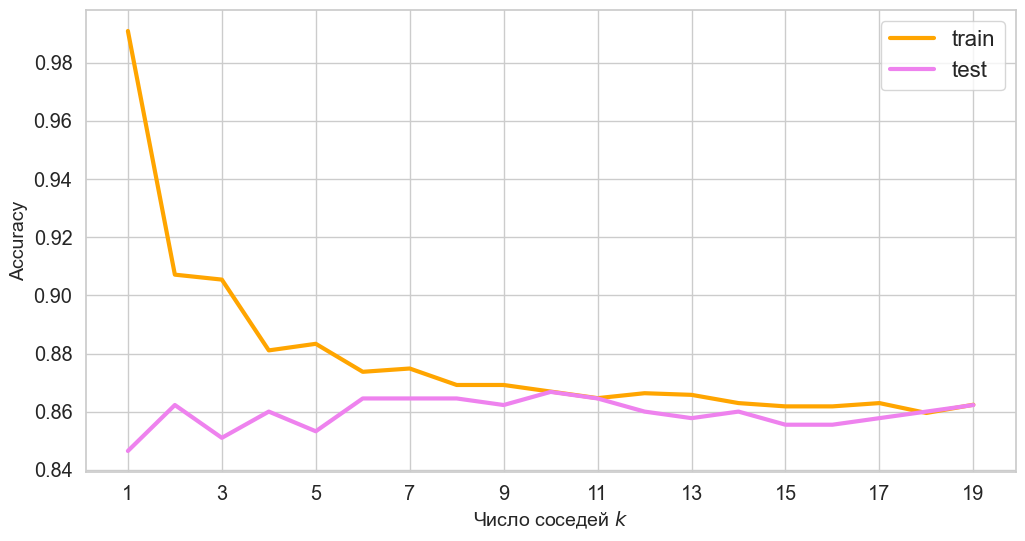

In [40]:
plt.figure(figsize=(12, 6))
plt.plot(n_neighbors_list, accs_train, label="train", color="orange", linewidth=3)
plt.plot(n_neighbors_list, accs_test, label="test", color="violet", linewidth=3)
plt.legend(fontsize=16)
plt.xticks(range(1, 20, 2))
plt.xlabel(r"Число соседей $k$", fontsize=14)
plt.ylabel("Accuracy", fontsize=14)
plt.show()

❓ **Вопрос** ❓

> О чем говорит зависимость кривых метрики от числа содедей $k$?

<details> <summary> Кликни для показа ответа </summary>

График зависимости метрики качества модели k-ближайших соседей (kNN) от параметра $k$ (числа соседей) демонстрирует характер изменения точности как на обучающей, так и на тестовой выборках.

На этапе обучения наблюдается тенденция к увеличению уровня обобщения модели с ростом значения $k$. Это означает, что при увеличении количества соседей модель становится менее склонной к запоминанию конкретных примеров данных, что уменьшает риск переобучения.

В случае тестовой выборки можно наблюдать две крайности: слева – зона переобучения, где модель слишком точно воспроизводит особенности обучающего набора данных, но плохо справляется с новыми данными; справа – область недобучения, когда модель недостаточно сложна для точного предсказания новых данных. Оптимальное значение $k$, соответствующее наилучшему балансу между пере- и недобучения, находится в средней части графика

</details><br/>

Оценим статзначимость разницы в предсказаниях двух моделей.

In [41]:
# ищем индекс максимальной точности на тесте
best_idx = np.argmax(accs_test)
best_k = list(n_neighbors_list)[best_idx]
best_acc = accs_test[best_idx]

df_score.loc[len(df_score)] = [f"KNN (k={best_k})", best_acc]
print(f"Лучший k = {best_k}, accuracy на тесте = {best_acc:.4f}")

Лучший k = 10, accuracy на тесте = 0.8668


In [42]:
knn = KNeighborsClassifier(n_neighbors=best_k, algorithm="brute")
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

In [43]:
baseline_errors = (y_pred_baseline != y_test).astype(int)
knn_errors = (y_pred_knn != y_test).astype(int)

stat, p = ttest_rel(baseline_errors, knn_errors)
print(f"p-value: {p:.4f}")

p-value: 0.0208


In [44]:
df_score

,model,score
0,Dummy (most_frequent),0.848758
1,Manual (two rules),0.801354
2,KNN (k=5),0.853273
3,KNN (k=10),0.866817


kNN c 7-ю соседями показал лучшее и статистически значимое улучшение 👑 по сравнению с бейзлайн моделью (p > 0.05), поэтому его можно рассматривать как рабочий кандидат для следующего шага анализа/продакшн-тестирования.

>❕ Подробности оценки статзначимости вы узнаете позже.

### 4. Выводы

Мы провели полный анализ датасета о маркетинговой кампании в retail: от EDA (очистка данных, визуализация распределений, корреляций и зависимостей от таргета `Response`) до построения простых ML-моделей. В EDA выявили ключевые паттерны: отклик чаще от клиентов с высоким доходом, без детей, с большими тратами (особенно на вино и мясо) и недавними покупками (`Recency`). Это помогло сформулировать гипотезы и подготовить данные для моделирования.

В ML-части:
- **Baselines**: Константная модель (предсказание самого частого класса — 0, т.е. "не откликнется") дала accuracy ~84,8% из-за дисбаланса классов (только 15% положительных откликов). Случайная модель хуже.
- **Ручное правило**: На основе двух признаков (`MntSweetProducts` и `Total_Spent`) accuracy ~80%, что показывает: простые эвристики работают, но не идеально, так как игнорируют остальные фичи.
- **kNN**: Метод kNN с подобранным гиперпараметром (k=10) улучшил accuracy до 86,7%. Это подтверждает: модель учитывает соседей (похожих клиентов) и предсказывает на основе их поведения.

**ML для бизнеса**:

- **Интерпретация**: Для клиента X модель говорит: "*Откликнется, т.к. 7 ближайших похожих (по доходу, тратах, recency) откликнулись*". Это объяснимо бизнесу: фокус на лояльных/богатых без детей.
- **ROI кампании**: Если отклик ~15% (как в данных), то используя МЛ модель можно выделить сегмент пользователей, которые с большей вероятностью откликнуться на кампанию. Это позволит снизить количество рассылок и сэкономить на рекламе
- **Риски**: Модель может ошибаться на редких клиентах (выбросы в EDA).

---
© 2025 команда <a href="https://thetahat.ru/">ThetaHat</a> для курса ML-1 ШАД